### GEOG 592 Homework - Anna Horton
I wanted to understand the relationship between the Mardi Gras parade routes and their proximity to the various New Orleans wards. Mardi Gras parades are notoriously overpopulated and full of tourists, which can get hairy fast. I want to complete an analysis on whether or not the parade routes would be able to expand vertically (meaning North to South) or horizontally (meaning East to West) at all into greenspaces to ensure that there was a lack of unsafe situations. As was revealed, there is very little proximity to the greenspaces (parks specifically) that New Orleans posesses. Maybe the Mardi Gras planners should think about maximing their use of greenspace and sending the parades into the wards with more wide open space. 

##### First step: upload and filter the data for just the attributes that I need
I am importing the geopandas, pandas, numpy, and matplotlib packages to make sure that I have all of the functionality required. I am also converting all of the CRS' to be identical so there are no mapping issues. The CRS number is 32615, which corresponds to the New Orleans UTM zone. 

In [142]:
## uploading the packages
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## uploading the data itself
routes = gpd.read_file("Mardi_Gras_Routes_20261003.geojson")
greenspace = gpd.read_file("Open_Greenspace_20261003.geojson")
wards = gpd.read_file("Wards_20261003.geojson")

## making sure all of the projections are the same
routes = routes.to_crs(epsg = 32615)
greenspace = greenspace.to_crs(epsg = 32615)
wards = wards.to_crs(epsg = 32615)


In [143]:

routes = routes[["parade", "location", "shape_stlength", "geometry"]]

## dropping the NaN values from the dataframe
routes.dropna(subset = ["parade"], how = "all", inplace = True)
routes.columns = ["name", "location", "shape_stlength", "geometry"]

In [144]:
greenspace = greenspace[["name", "geometry", "shape_starea"]]
## dropping the NaN values from the dataframe
greenspace.dropna(subset = ["name"], how = "all", inplace = True)

In [145]:
wards = wards[["ward", "shape_area", "geometry"]]
wards.columns = ["name", "shape_area", "geometry"]

##### Plotting the various geometries to visualize the variables

I am creating a map for each of the variables so that I can understand their geographic relationship to each other. 

Text(0.5, 1.0, 'New Orleans Wards')

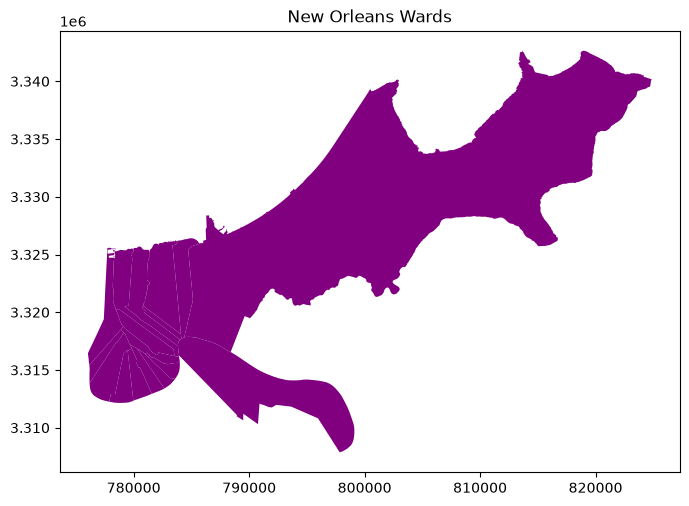

In [146]:
## plotting the ward boundaries
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")
plt.title("New Orleans Wards")

Text(0.5, 1.0, 'New Orleans Greenspace')

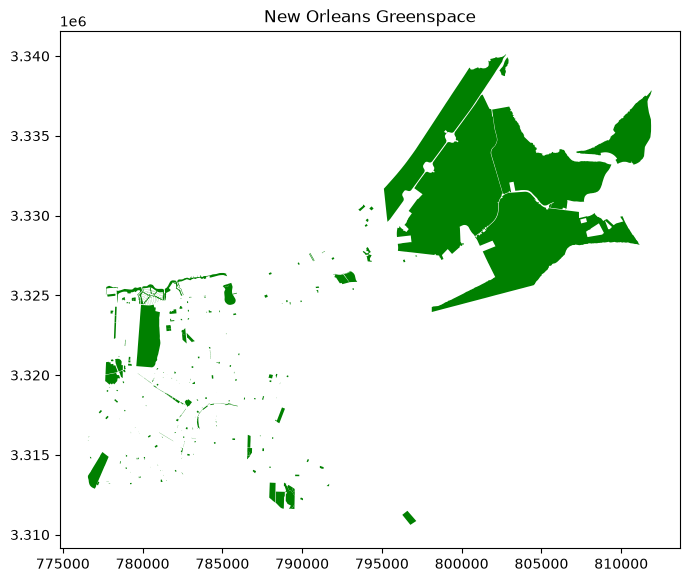

In [147]:
### plotting the greenspace boundaries
fig, ax = plt.subplots(figsize=(8,7))
greenspace.plot(ax=ax, color="green")
plt.title("New Orleans Greenspace")

Text(0.5, 1.0, 'Parade Routes')

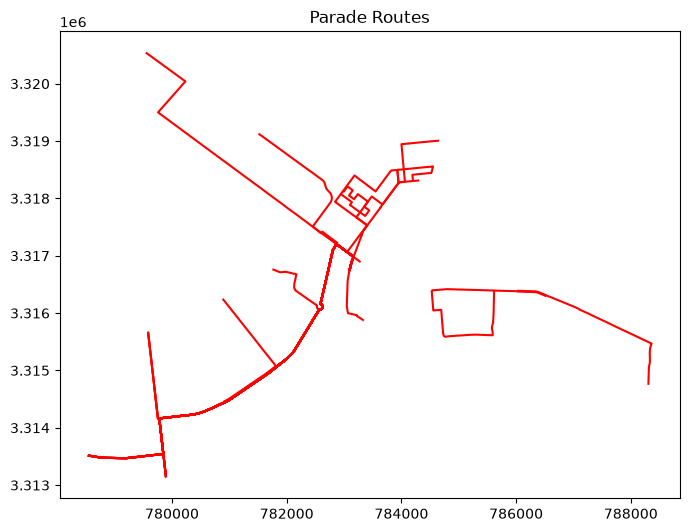

In [148]:
### plotting the parade routes
fig, ax = plt.subplots(figsize=(8,7))
routes.plot(ax=ax, color="red")
plt.title("Parade Routes")

This last map produces the overlay of each of the three layers. It allows the reader to see where these spatial layers overlap (and where they don't), and where they may be potential for shifting routes to maximize safety.

Text(0.5, 1.0, 'New Orleans Wards, Greenspaces, and Parade Routes')

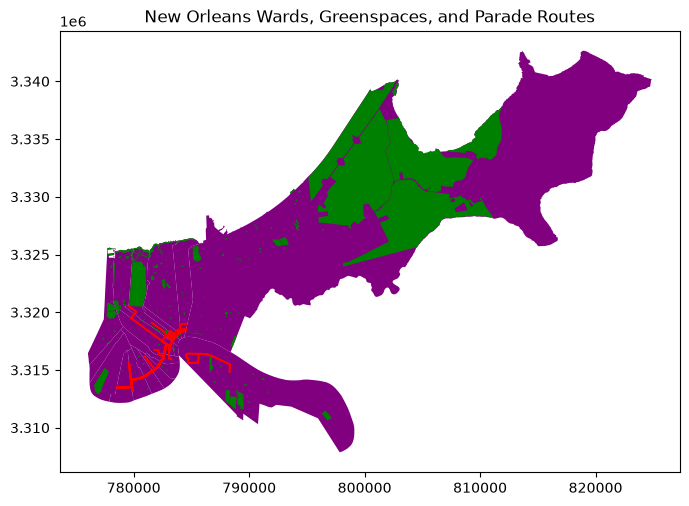

In [149]:
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")
greenspace.plot(ax=ax, color="green")
routes.plot(ax=ax, color="red")
plt.title("New Orleans Wards, Greenspaces, and Parade Routes")

The above map demonstrates that there is some overlaying of the layers, but there are notably large spatial gaps between each of the layers. 

#### Analysis
What I want to get at is the following: 
1) Are New Orleans parades using their greenspace appropriately?
2) Where can parade routes expand to ensure that they are able to maximize their use of greenspace?
3) If they are not close to greenspace, what other spatial areas can they expand or shift to to ensure maximum safety of the participants and the spectators?

In [150]:
## first step: create a spatial join between the routes and the wards to how many routes are completely within (do not overlap with other wards) each ward
ward_c_routes = gpd.sjoin(wards, routes, how = "left", predicate = "contains")
ward_c_routes
## spatial join with a meaningful tabular result

# from this analysis there are only two wards that posess a parade route completely contained, and those are wards 5 and 15

,name_left,shape_area,geometry,index_right,name_right,location,shape_stlength
0,6,17965648.880237851,"MULTIPOLYGON (((784126.664 3317714.657, 784016...",NaN,NaN,NaN,NaN
1,11,37330838.03291522,"MULTIPOLYGON (((781365.55 3315279.831, 781485....",NaN,NaN,NaN,NaN
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",NaN,NaN,NaN,NaN
3,13,51777794.015902705,"MULTIPOLYGON (((779485.152 3316604.1, 779497.6...",NaN,NaN,NaN,NaN
4,16,31769146.82387539,"MULTIPOLYGON (((778564.518 3317396.03, 778558....",NaN,NaN,NaN,NaN
5,10,26209810.956029069,"MULTIPOLYGON (((782646.496 3313393.301, 782643...",NaN,NaN,NaN,NaN
6,15,578581641.529585,"MULTIPOLYGON (((788379.883 3316540.771, 788385...",14.0,NOMTOC,West Bank,25847.150251192994
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6.0,Barkus,Downtown,5768.4592363558468
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",NaN,NaN,NaN,NaN
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",NaN,NaN,NaN,NaN


In [151]:
## what about intersection? There are likely to be more intersections as these are many wards and many parade routes, so some pieces of each should intersect
wards_union = wards.geometry.union_all() 
ward_i_routes = routes[routes.geometry.intersects(wards_union)] ## this analysis tells me the parades that overlap each ward
## layer one

## testing how many routes intersect with each ward
wards["route_count"] = wards.geometry.apply(lambda geom: routes.geometry.intersects(geom).sum()) ## asked Claude to help me with this issue, creates a route_count column
wards.sort_values("route_count", ascending = False) ## if you don't assign the sorted values to the original variable again, it'll print them in the original order not the sorted one

,name,shape_area,geometry,route_count
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",31
5,10,26209810.956029069,"MULTIPOLYGON (((782646.496 3313393.301, 782643...",30
15,2,37961901.92523744,"MULTIPOLYGON (((781645.43 3316511.746, 781690....",30
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",30
1,11,37330838.03291522,"MULTIPOLYGON (((781365.55 3315279.831, 781485....",29
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",29
3,13,51777794.015902705,"MULTIPOLYGON (((779485.152 3316604.1, 779497.6...",15
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",5
11,8,105797659.11738931,"MULTIPOLYGON (((785671.153 3325966.081, 785676...",3


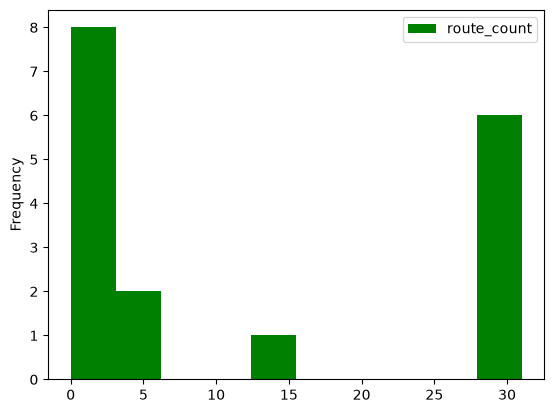

In [152]:
## making a histogram of the route count data - there are many wards that only have a few intersections and a similar amount that have a 30 count of intersections
wards.plot(kind="hist", color = "green")
plt.show()

In [ ]:
## there are many route overlaps - now I need to involve greenspace
## I want to know which wards have the most greenspace
greenspace.dropna(subset = ["name"])
mask = greenspace["name"].str.contains("Park") ## subsetting for only parks, as those tend to be larger and more easily recognizable
greenspace = greenspace[mask]

## creating a spatial join between the wards and the greenspace layer to identify which wards contain a park
green_wards = gpd.sjoin(wards, greenspace, predicate = "contains") ## I wanted to see which wards contained a park specifically
green_wards = green_wards.sort_values("name_left")
green_wards.groupby("name_left")
green_wards.value_counts("name_left")

## based on this analysis, ward 5 has the most greenspace, with 11 parks included in its boundaries

,name_left,shape_area,geometry,route_count,index_right,name_right,shape_starea,park_count
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",30,1520,Camp Street Finger Park,23851.892093741426,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,2834,Jack Bartlett Park,4926.9343253156312,0
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",5,2328,New Basin Canal Park,2073643.0776125467,0
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",5,5209,Peridot Park,62996.232097224231,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,1297,Breeze Park,339002.03445475269,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,2679,Foliage Park,658106.7171966912,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,97,Ozone Park,489369.99714954989,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,463,Zephyr Park,240520.18345673103,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,2582,Central Park,86118.705600570465,0
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6,3627,Carondelet Canal Park,159332.2257174321,0


In [154]:
## next, I will create a buffer around the greenspace parks and see if there is a possibility that there could be some crossing there
## I know that there are intersections between the parade routes and the wards, so these seems like a logical next step
green_buffer = greenspace.geometry.buffer(distance = 500) ## decided on a distance of 500 feet for my buffer, seems to be a good availability for expansion

## creating the crossing layer
crossing_the_green = green_buffer.geometry.crosses(ward_i_routes, align = True) ## this explains if parade routes that already intersect the wards also cross a 500 foot buffer around any park
print(crossing_the_green.value_counts())
## layer two

## there is no overlap! All intersect values are False

False    98
Name: count, dtype: int64


In [155]:
## given that there are no wards even within a 500 foot buffer of a greenspace, the time might have come to increase the buffer
green_buffer_1 = greenspace.geometry.buffer(distance = 2000)
wards_close_to_green1 = green_buffer_1.geometry.within(wards)
wards_close_to_green1.value_counts()

## even with a quadrupled buffer, there is simply no overlap between New Orleans wards and greenspace 

/var/folders/gr/m2n_2p5571g1k1fldyhfmx980000gn/T/ipykernel_66128/615125020.py:3: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  wards_close_to_green1 = green_buffer_1.geometry.within(wards)


False    79
Name: count, dtype: int64

##### As of right now, it seems that the parade routes that already intersect with wards do not cross with instances of greenspace (even with a 500 foot AND a 2000 foot buffer).

The results of my analysis demonstrate that there is no use of greenspace by the New Orleans parade routes. They are content with pushing people into the sides of the streets and possibly creating hazardous situations. Based on the above analysis, I am going to pull out which wards and which parades are the largest, and so should thus expand into the greenspaces.  

In [156]:
## based on the green_wards layer
## I used the parade length as a proxy for the parade size (based on distance)
routes = routes.sort_values("shape_stlength", ascending = False)
long_routes = routes[0:5] ## these are the longest parade routes

## also sorted the wards by the size and selected the smallest wards
wards_small = wards.sort_values("shape_area")
small_wards = wards_small[0:5] ## these are the smallest wards by area

wards_big = wards.sort_values("shape_area", ascending = False)
big_wards = wards_big[0:5] ## there are the biggest wards by area

## both of these wards posess a parade route fully contained within them
ward_five = ward_c_routes[(ward_c_routes["name_left"] == "5")]
ward_fifteen = ward_c_routes[(ward_c_routes["name_left"] == "15")]
contained_routes = ward_c_routes[(ward_c_routes["name_right"] == "NOMTOC") & (ward_c_routes["name_right"] == "Barkus")] ## the specific parades that are contained within wards 5 and 15

Text(0.5, 1.0, 'The smallest wards and the parade routes')

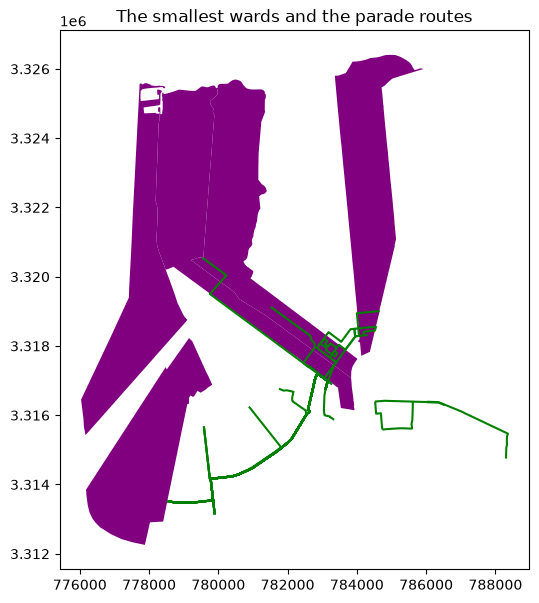

In [157]:
## making a plot to make sure all of my False results are tracking with the spatial data, and that would appear correct (these parades are one long line, not multiple sections)
fig, ax = plt.subplots(figsize=(8,7))
small_wards.plot(ax=ax, color="purple")
routes.plot(ax=ax, color = "green")
plt.title("The smallest wards and the parade routes")

## small ward plot

Text(0.5, 1.0, 'The biggest wards and the parade routes')

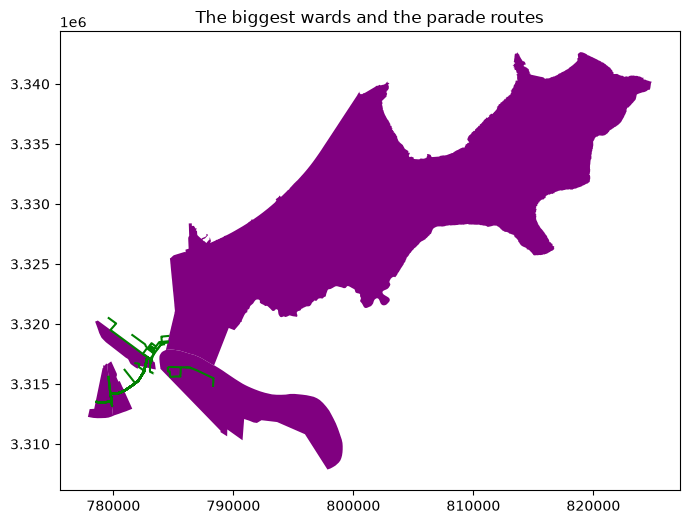

In [158]:
fig, ax = plt.subplots(figsize=(8,7))
big_wards.plot(ax=ax, color="purple")
routes.plot(ax=ax, color = "green")
plt.title("The biggest wards and the parade routes")

## big ward plot

##### The analysis below is determining which parades have space where they could possibly expand into a nearby geographic area. 

In [159]:
## seeing if the routes that are contained within a ward are able to expand into the largest and smallest wards
long_routes_buffer = long_routes.geometry.buffer(distance = 500) ## creating a buffer for the longest routes (size proxy)
contained_routes_buffer = contained_routes.buffer(distance = 500) ## creating a buffer for the contained routes

## I did the smallest ones first beased on the map above - they look to be more closely tied geographically with smaller wards than the bigger wards
## seeing if the longest routes with a buffer will intersect with the smallest wards
long_expansion1 = long_routes_buffer.geometry.intersects(small_wards)
print(long_expansion1.value_counts())

## seeing if the contained routes with a buffer will intersect with the smallest wards
contained_expansion1 = contained_routes_buffer.geometry.intersects(small_wards)
print(contained_expansion1.value_counts())

## seeing if the longest routes with a buffer have space to expand into the biggest wards
long_expansion = long_routes_buffer.geometry.intersects(big_wards)
long_expansion.value_counts()
## layer three

## what about the contained routes?
contained_expansion = contained_routes_buffer.geometry.intersects(small_wards)
print(contained_expansion.value_counts())

## both the buffered longest routes and the contained routes do not intersect with the biggest wards - they do not really have space to expand throughout their area

False    7
True     1
Name: count, dtype: int64
False    5
Name: count, dtype: int64
False    5
Name: count, dtype: int64


/var/folders/gr/m2n_2p5571g1k1fldyhfmx980000gn/T/ipykernel_66128/232908337.py:7: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  long_expansion1 = long_routes_buffer.geometry.intersects(small_wards)
/var/folders/gr/m2n_2p5571g1k1fldyhfmx980000gn/T/ipykernel_66128/232908337.py:11: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'ali

Based on the above analysis, the longest parades and the completely contained parades are not close enough to expand either into the largest wards, which is disappointing, or the smallest wards, which is encouraging. We do not want them expanding into places where they are likely people already crowded, but it is unfortunate that they are not at all close to the larger wards. 

### Overall, New Orleans is not using its greenspace to its full potential. 

### Tabular join!

I chose to perform my tabular join with the measles cases in the United States to the state boundary layer. The measles case file had the number of cases delineated for each year for the last three years (2024, 2025 and 2026), but I chose to utilize only the cases from 2026 as I know that they have been in the news much more recently. I want to see what the spatial pattern is between the states and the measles cases. 

In [160]:
### loading in the data

## data cleaning - it was slightly messy
measles = gpd.read_file("MeaslesCasesMap.csv")
measles.columns = ["2024", "2025", "2026", "x", "shapeName"]
measles = measles.drop(columns = ["x"])
measles.drop(index = 0, inplace = True)

## loading in my second datatset
states = gpd.read_file("state_boundaries.geojson")
states = states[["shapeName", "geometry"]]

In [161]:
## creating a table join 
measles_states = measles.merge(states, how = "inner")
measles_states

,2024,2025,2026,shapeName,geometry
0,0,1,1,Alabama,"MULTIPOLYGON (((-88.05338 30.50699, -88.05235 ..."
1,0,4,1,Alaska,"MULTIPOLYGON (((179.48245 51.98283, 179.47555 ..."
2,5,222,110,Arizona,"POLYGON ((-109.04523 36.99909, -109.18121 36.9..."
3,0,8,0,Arkansas,"POLYGON ((-90.3093 34.9957, -90.30993 35.00107..."
4,13,26,54,California,"MULTIPOLYGON (((-118.60443 33.47856, -118.6072..."
5,0,35,24,Colorado,"POLYGON ((-102.0421 36.99302, -102.04196 37.02..."
6,0,1,3,Connecticut,"MULTIPOLYGON (((-72.76143 41.24234, -72.76034 ..."
7,0,0,23,Delaware,"MULTIPOLYGON (((-75.56555 39.51486, -75.56745 ..."
8,1,0,1,District of Columbia,"POLYGON ((-77.03901 38.79165, -77.03758 38.792..."
9,11,8,148,Florida,"MULTIPOLYGON (((-80.17628 25.52506, -80.17706 ..."


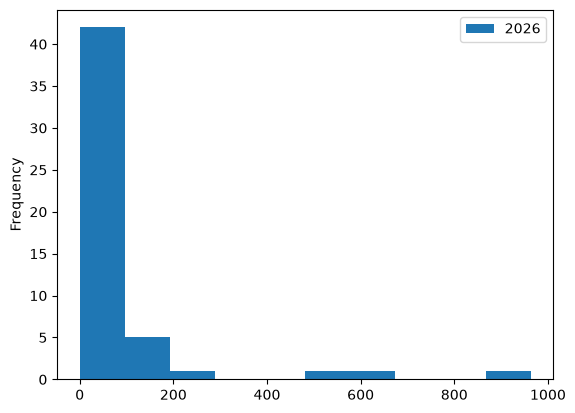

In [162]:
## selecting just the 2026 column
measles_states_2026 = measles_states[["2026", "shapeName", "geometry"]]
measles_states_2026["2026"] = pd.to_numeric(measles_states_2026["2026"], errors = "coerce")
measles_states_2026

## making a bar graph
measles_states_2026.plot(kind="hist")
plt.show()

#### AI statement


1) I used Claude AI for this assignment. 
2) I had copied and pasted in my code, explained why it was not working, and asked for help in deciphering why. I wanted to be able to use the geoprocessing techniques without having to do a spatial join, and as far as I had learned, there was no available technique for a one-to-many comparison with just the regular geoprocessing techniques. I quickly learned that that was not the case. I also asked it for help counting the various intersections, as I was planning to use that information later on.
3) It helped me correct my creating the routes that intersect the wards layer and the route_count column in that layer. I wasn't sure how to 1) make a one-to-many geoprocessing layer and 2) create a route_count variable that told me how many intersections persisted for each ward. 
4) I added the union.all() function in the first line of code. That inclusion allowed for the one-to-many as it collapsed the wards into one layer so that the routes could be compared. I also added the lambda geom parameters in the next section of code to help create the route_count column, as I had no idea how to count the intersections and then add those to a column in the new dataset I had just created. 